# (Ignore warnings)

In [31]:
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

# Includes

In [32]:
from ucimlrepo import fetch_ucirepo, list_available_datasets
from sklearn.datasets import fetch_openml
from tabulate import tabulate

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.utils import resample

from collections import Counter
from sklearn.model_selection import cross_val_score, KFold
from joblib import Parallel, delayed
from sklearn.metrics import classification_report

from graphviz import Digraph

In [33]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
pd.set_option('display.max_rows', 20)
pd.set_option('display.max_columns', 50)
  
credit_approval = fetch_ucirepo(id=27) 

#exercici1  
X = credit_approval.data.features 
y = credit_approval.data.targets



In [34]:
display(X, y)

,A15,A14,A13,A12,A11,A10,A9,A8,A7,A6,A5,A4,A3,A2,A1
0,0,202.000,g,f,1,t,t,1.250,v,w,g,u,0.000,30.830,b
1,560,43.000,g,f,6,t,t,3.040,h,q,g,u,4.460,58.670,a
2,824,280.000,g,f,0,f,t,1.500,h,q,g,u,0.500,24.500,a
3,3,100.000,g,t,5,t,t,3.750,v,w,g,u,1.540,27.830,b
4,0,120.000,s,f,0,f,t,1.710,v,w,g,u,5.625,20.170,b
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685,0,260.000,g,f,0,f,f,1.250,h,e,p,y,10.085,21.080,b
686,394,200.000,g,t,2,t,f,2.000,v,c,g,u,0.750,22.670,a
687,1,200.000,g,t,1,t,f,2.000,ff,ff,p,y,13.500,25.250,a
688,750,280.000,g,f,0,f,f,0.040,v,aa,g,u,0.205,17.920,b


,A16
0,+
1,+
2,+
3,+
4,+
...,...
685,-
686,-
687,-
688,-


## EDA

Class Percentages:
A16
-     55.507
+     44.493
Name: proportion, dtype: float64


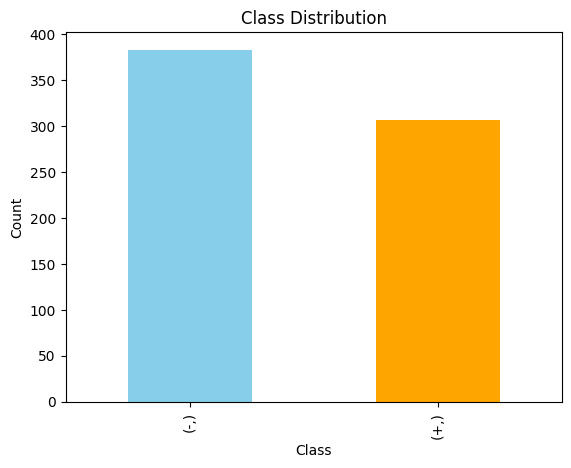

In [35]:
class_percentages = y.value_counts(normalize=True) * 100

print("Class Percentages:")
print(class_percentages)


class_counts = y.value_counts()
class_counts.plot(kind='bar', color=['skyblue', 'orange'])
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

Carreguem dataset, guardem variables a X, variable objectiu a y i dataset complet a heart_disease_df

In [36]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A15     690 non-null    int64  
 1   A14     677 non-null    float64
 2   A13     690 non-null    object 
 3   A12     690 non-null    object 
 4   A11     690 non-null    int64  
 5   A10     690 non-null    object 
 6   A9      690 non-null    object 
 7   A8      690 non-null    float64
 8   A7      681 non-null    object 
 9   A6      681 non-null    object 
 10  A5      684 non-null    object 
 11  A4      684 non-null    object 
 12  A3      690 non-null    float64
 13  A2      678 non-null    float64
 14  A1      678 non-null    object 
dtypes: float64(4), int64(2), object(9)
memory usage: 81.0+ KB


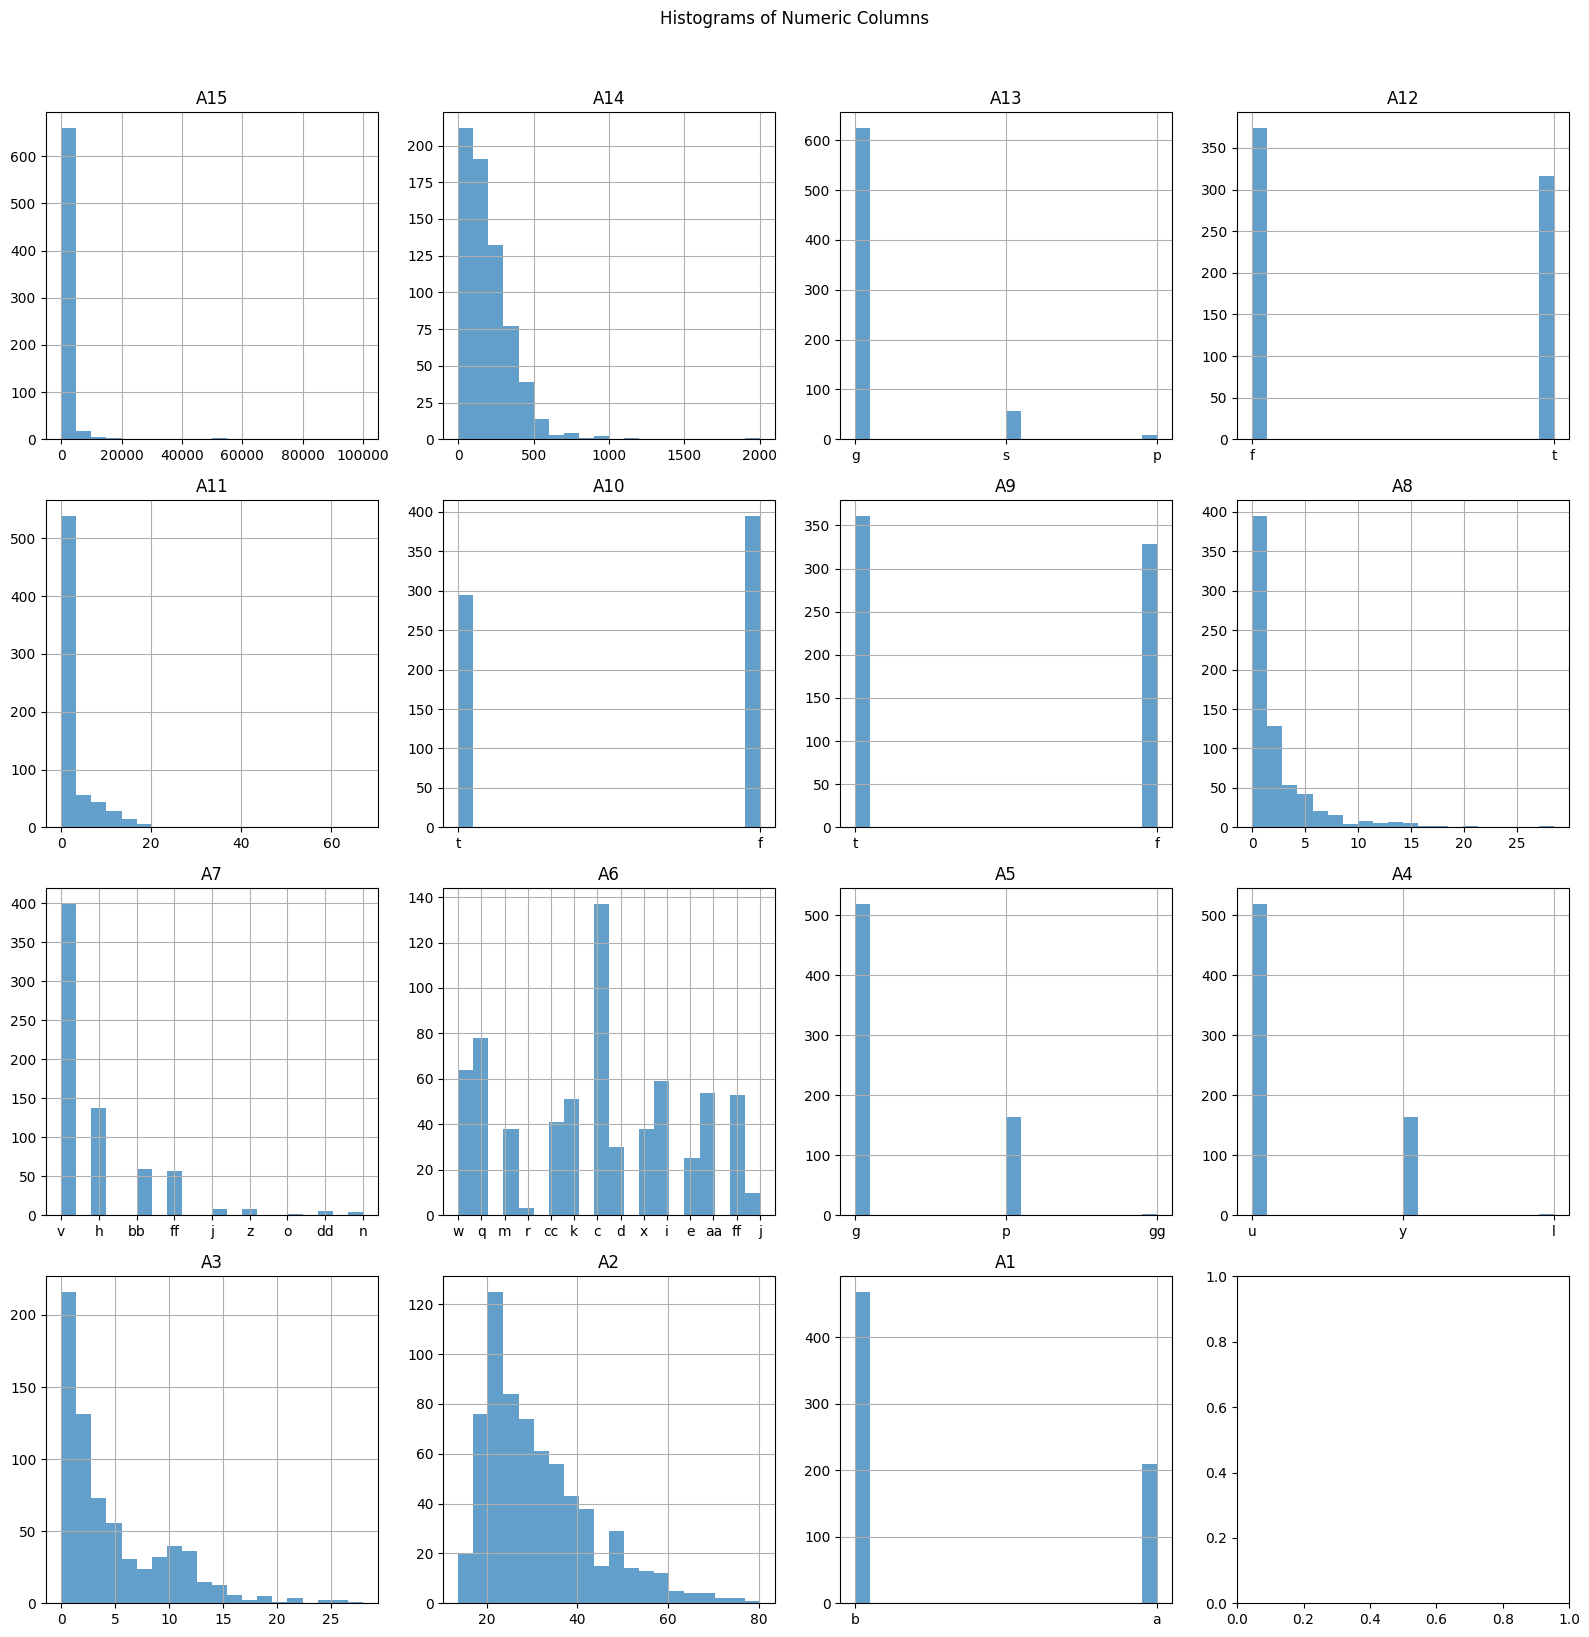

In [37]:
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
fig.suptitle('Histograms of Numeric Columns', y=1.02)

for i, column in enumerate(X.columns):
    ax = axes[i // 4, i % 4]
    X[column].hist(ax=ax, bins=20, alpha=0.7)
    ax.set_title(column)

plt.tight_layout()
plt.show()


Visualitzem la quantitat de NaNs que tenim en la base de dades per columna.

In [38]:
nan_counts = X.isna().sum()
print("Nombre de NaN per columna:")
display(nan_counts)

Nombre de NaN per columna:


A15     0
A14    13
A13     0
A12     0
A11     0
A10     0
A9      0
A8      0
A7      9
A6      9
A5      6
A4      6
A3      0
A2     12
A1     12
dtype: int64

Ara mostrem les files que contenen NaN en algun atribut.

In [39]:
display(X[X.isna().any(axis=1)])

,A15,A14,A13,A12,A11,A10,A9,A8,A7,A6,A5,A4,A3,A2,A1
71,0,NaN,g,t,0,f,t,12.500,bb,d,g,u,4.000,34.830,b
83,0,300.000,g,t,0,f,t,3.000,v,d,g,u,3.500,NaN,a
86,0,928.000,s,t,0,f,t,0.875,v,d,g,u,0.375,NaN,b
92,0,0.000,g,f,0,f,t,8.500,v,aa,p,y,5.000,NaN,b
97,0,320.000,s,t,0,f,t,0.835,bb,c,g,u,0.500,NaN,b
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
608,0,460.000,g,t,0,f,f,4.250,v,d,p,y,0.040,NaN,b
622,0,NaN,p,f,0,f,f,0.000,NaN,NaN,NaN,NaN,0.000,25.580,a
626,0,NaN,g,t,0,f,f,0.165,bb,i,p,y,7.835,22.000,b
641,141,200.000,g,t,0,f,f,3.500,v,cc,p,y,2.250,33.170,NaN


# EXERCICI 1

### Preprocessing Pipeline:

* Standaritzar
* Normalitzar
* Tractar NaNs

In [40]:
class NaNsImputer(BaseEstimator, TransformerMixin):
     
    def fit(self, X):
        return self
    
    def transform(self, X):
        imputer = SimpleImputer(strategy='most_frequent')
        X_transformed = imputer.fit_transform(X)
        
        return pd.DataFrame(X_transformed, columns=X.columns)

class NaNsDropper(BaseEstimator, TransformerMixin):
    
    def fit(self, X):
        return self
    
    def transform(self, X):
        X = X.dropna()
        return X
    
class Normalizer(BaseEstimator, TransformerMixin):
    
    def fit(self, X):
        return self
    
    def transform(self, X):
        scaler = MinMaxScaler()
        X_transformed = scaler.fit_transform(X)
        return pd.DataFrame(X_transformed, columns=X.columns)

class QuantileCutter(BaseEstimator, TransformerMixin):
    def __init__(self, num_quantiles=5):
        self.num_quantiles = num_quantiles
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X, y=None):
        continuous_columns = X.select_dtypes(include=['float64']).columns
        
        for column in continuous_columns:
            X.loc[:, column] = pd.qcut(X[column], q=self.num_quantiles, labels=False, duplicates='drop')
        
        return X
    
class OneHotEncoderCustom(BaseEstimator, TransformerMixin):
    def fit(self, X):
        return self
    
    def transform(self, X):
        attributes_to_encode = ['A13', 'A12', 'A10', 'A9', 'A7', 'A6', 'A5', 'A4', 'A1']
        X_encoded = pd.get_dummies(X, columns=attributes_to_encode)
        return X_encoded

In [41]:
pipe = Pipeline([
    ("NaNsDropper", NaNsDropper()),
    # ("Discretizer", Discretizer()),
    # ("OneHotEncoder", OneHotEncoderCustom()),
    # ("Normalizer", Normalizer())
])

X = pipe.fit_transform(X)
y = y.loc[X.index]
print(f'Number of NaNs: {X.isna().sum().sum()}')
labels = X.columns
X

Number of NaNs: 0


,A15,A14,A13,A12,A11,A10,A9,A8,A7,A6,A5,A4,A3,A2,A1
0,0,202.000,g,f,1,t,t,1.250,v,w,g,u,0.000,30.830,b
1,560,43.000,g,f,6,t,t,3.040,h,q,g,u,4.460,58.670,a
2,824,280.000,g,f,0,f,t,1.500,h,q,g,u,0.500,24.500,a
3,3,100.000,g,t,5,t,t,3.750,v,w,g,u,1.540,27.830,b
4,0,120.000,s,f,0,f,t,1.710,v,w,g,u,5.625,20.170,b
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685,0,260.000,g,f,0,f,f,1.250,h,e,p,y,10.085,21.080,b
686,394,200.000,g,t,2,t,f,2.000,v,c,g,u,0.750,22.670,a
687,1,200.000,g,t,1,t,f,2.000,ff,ff,p,y,13.500,25.250,a
688,750,280.000,g,f,0,f,f,0.040,v,aa,g,u,0.205,17.920,b


## Decision Tree

In [42]:
class Node():
    def __init__(self, feature_index=None, threshold=None, left=None, right=None, info_gain=None, value=None):
        ''' constructor ''' 
        
        # for decision node
        self.feature_index = feature_index
        self.threshold = threshold
        self.left = left
        self.right = right
        self.info_gain = info_gain
        
        # for leaf node
        self.value = value

In [43]:
class DecisionTreeClassifier():
    def __init__(self, min_samples_split=2, max_depth=2, mode='entropy'):
        ''' constructor '''
        
        # initialize the root of the tree 
        self.root = None
        
        # stopping conditions
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.mode = mode
        
    def build_tree(self, dataset, curr_depth=0):
        ''' recursive function to build the tree ''' 
    
        X, Y = dataset[:, :-1], dataset[:, -1]
        num_samples, num_features = np.shape(X)
        
        # split until stopping conditions are met
        if num_samples >= self.min_samples_split and curr_depth <= self.max_depth:
            # find the best split
            best_split = self.get_best_split(dataset, num_samples, num_features)
            # check if information gain is positive
            if "info_gain" in best_split and best_split["info_gain"] > 0:
                # recur left
                left_subtree = self.build_tree(best_split["dataset_left"], curr_depth + 1)
                # recur right
                right_subtree = self.build_tree(best_split["dataset_right"], curr_depth + 1)
                # return decision node
                return Node(
                    best_split["feature_index"], 
                    best_split["threshold"], 
                    left_subtree, 
                    right_subtree, 
                    best_split["info_gain"]
                )
        
        # compute leaf node
        leaf_value = self.calculate_leaf_value(Y)
        # return leaf node
        return Node(value=leaf_value)
    
    def get_best_split(self, dataset, num_samples, num_features):
        ''' function to find the best split '''
        
        # dictionary to store the best split
        best_split = {}
        max_info_gain = -float("inf")
        
        # loop over all the features
        for feature_index in range(num_features):
            feature_values = dataset[:, feature_index]
            possible_thresholds = np.unique(feature_values)
            # loop over all the feature values present in the data
            for threshold in possible_thresholds:
                # get current split
                dataset_left, dataset_right = self.split(dataset, feature_index, threshold)
                # check if childs are not null
                if len(dataset_left)>0 and len(dataset_right)>0:
                    y, left_y, right_y = dataset[:, -1], dataset_left[:, -1], dataset_right[:, -1]
                    # compute information gain
                    curr_info_gain = self.information_gain(y, left_y, right_y)
                    # update the best split if needed
                    if curr_info_gain>max_info_gain:
                        best_split["feature_index"] = feature_index
                        best_split["threshold"] = threshold
                        best_split["dataset_left"] = dataset_left
                        best_split["dataset_right"] = dataset_right
                        best_split["info_gain"] = curr_info_gain
                        max_info_gain = curr_info_gain
                        
        # return best split
        return best_split
    
    def split(self, dataset, feature_index, threshold):
        ''' function to split the data '''
        
        dataset_left = np.array([row for row in dataset if row[feature_index]<=threshold])
        dataset_right = np.array([row for row in dataset if row[feature_index]>threshold])
        return dataset_left, dataset_right
    
    def information_gain(self, parent, l_child, r_child):
        ''' function to compute information gain '''

        weight_l = len(l_child) / len(parent)
        weight_r = len(r_child) / len(parent)
        if self.mode=="gini":
            gain = self.gini_index(parent) - (weight_l*self.gini_index(l_child) + weight_r*self.gini_index(r_child))
        else:
            gain = self.entropy(parent) - (weight_l*self.entropy(l_child) + weight_r*self.entropy(r_child))
        return gain
    
    def entropy(self, y):
        ''' function to compute entropy '''
        
        class_labels = np.unique(y)
        entropy = 0
        for cls in class_labels:
            p_cls = len(y[y == cls]) / len(y)
            entropy += -p_cls * np.log2(p_cls)
        return entropy
    
    def gini_index(self, y):
        ''' function to compute gini index '''
        
        class_labels = np.unique(y)
        gini = 0
        for cls in class_labels:
            p_cls = len(y[y == cls]) / len(y)
            gini += p_cls**2
        return 1 - gini
        
    def calculate_leaf_value(self, Y):
        ''' function to compute leaf node '''
        
        Y = list(Y)
        return max(Y, key=Y.count)
    
    def print_tree(self, tree=None, indent=" "):
        ''' function to print the tree '''
        
        if not tree:
            tree = self.root

        if tree.value is not None:
            print(tree.value)

        else:
            print("X_"+str(tree.feature_index), "<=", tree.threshold, "?", tree.info_gain)
            print("%sleft:" % (indent), end="")
            self.print_tree(tree.left, indent + indent)
            print("%sright:" % (indent), end="")
            self.print_tree(tree.right, indent + indent)
            
    def graphviz_tree(self, tree=None, dot=None):
        ''' function to generate a graphviz object representing the tree '''
        
        if not tree:
            tree = self.root

        if dot is None:
            dot =Digraph()
            dot.attr('node', shape='circle')
            dot.node(name=str(tree), label=str(tree.value))

        #else:
        if tree.value is not None:
            dot.node(name=str(tree), label=str(tree.value))
        else:
            dot.node(name=str(tree), label=labels[tree.feature_index] + "<=" + str(tree.threshold) + "?" + "\nInformation gain: " + str(tree.info_gain))

        if tree.left is not None:
            dot.edge(str(tree), str(tree.left))
            dot = self.graphviz_tree(tree.left, dot=dot)

        if tree.right is not None:
            dot.edge(str(tree), str(tree.right))
            dot = self.graphviz_tree(tree.right, dot=dot)

        return dot
    
    def fit(self, X, Y):
        ''' function to train the tree '''
        
        dataset = np.concatenate((X, Y), axis=1)
        self.root = self.build_tree(dataset)
    
    def predict(self, X):
        ''' function to predict new dataset '''
        
        preditions = [self.make_prediction(x, self.root) for x in X]
        return preditions
    
    def make_prediction(self, x, tree):
        ''' function to predict a single data point '''
        
        if tree.value!=None: return tree.value
        feature_val = x[tree.feature_index]
        if feature_val<=tree.threshold:
            return self.make_prediction(x, tree.left)
        else:
            return self.make_prediction(x, tree.right)
     

### visualizing tree

In [44]:
classifier = DecisionTreeClassifier(min_samples_split=5, max_depth=10, mode='gini')
classifier.fit(X, y)

# Print the tree
dot = classifier.graphviz_tree()
dot.render(filename='tree_output', format='png', cleanup=True)

'tree_output.png'

### CrossValidation fucntions

In [45]:
def cross_validate_decision_tree(X, y, n_splits=5, min_samples_split=10, max_depth=10, mode='entropy'):
    ''' function to perform k-fold cross-validation for DecisionTreeClassifier '''
    
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    accuracy_scores = []
    f1_scores = []

    for train_index, test_index in kf.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        # Initialize and fit the DecisionTreeClassifier
        classifier = DecisionTreeClassifier(min_samples_split=min_samples_split, max_depth=max_depth, mode=mode)
        classifier.fit(X_train, y_train)

        # Make predictions
        y_pred = classifier.predict(X_test)

        # Calculate accuracy and F1-score and store them
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='macro')

        accuracy_scores.append(accuracy)
        f1_scores.append(f1)

    return accuracy_scores, f1_scores

def train_and_evaluate(X_train, y_train, X_test, y_test, min_samples_split=2, max_depth=10, mode='entropy'):
    # Initialize and fit the DecisionTreeClassifier
    classifier = DecisionTreeClassifier(min_samples_split=min_samples_split, max_depth=max_depth, mode=mode)
    classifier.fit(X_train, y_train)

    # Make predictions
    y_pred = classifier.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)

    # Calculate F1 score macro
    f1_macro = f1_score(y_test, y_pred, average='macro')

    return accuracy, f1_macro

def leave_one_out_decision_tree_parallel(X, y, min_samples_split=2, max_depth=10, n_jobs=-1, mode='entropy'):
    loo = LeaveOneOut()

    # Using joblib to parallelize the leave-one-out loop
    results = Parallel(n_jobs=n_jobs)(
        delayed(train_and_evaluate)(
            X[train_index], y[train_index], X[test_index], y[test_index],
            min_samples_split, max_depth, mode=mode
        )
        for train_index, test_index in loo.split(X)
    )

    accuracy_scores, f1_macro_scores = zip(*results)

    return accuracy_scores, f1_macro_scores



In [46]:
data = pd.concat([X, y], axis=1)

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values.reshape(-1, 1)

## Entropy

#### Cross-Validation

In [47]:
accuracy_scores, f1_scores = cross_validate_decision_tree(X, y, n_splits=5, min_samples_split=5, max_depth=10, mode='entropy')
print("Accuracy scores:", accuracy_scores)
print("Mean accuracy:", np.mean(accuracy_scores))
print("F1 scores:", f1_scores)
print("Mean F1 score:", np.mean(f1_scores))

Accuracy scores: [0.7938931297709924, 0.8244274809160306, 0.7862595419847328, 0.7692307692307693, 0.8076923076923077]
Mean accuracy: 0.7963006459189665
F1 scores: [0.7907719609582964, 0.8244274809160305, 0.7825983878615457, 0.7610879686351384, 0.8076809278655541]
Mean F1 score: 0.793313345247313


#### LeaveOneOut

In [48]:
# accuracy_scores, f1_macro_scores = leave_one_out_decision_tree_parallel(X, y, 5, mode='entropy')
# print("Accuracy scores:", accuracy_scores)
# print("Mean accuracy:", np.mean(accuracy_scores))
# print("F1 scores:", f1_scores)
# print("Mean F1 score:", np.mean(f1_scores))

## Gini

#### Cross-Validation

In [49]:
accuracy_scores, f1_scores = cross_validate_decision_tree(X, y, n_splits=5, min_samples_split=5, max_depth=10, mode='gini')
print("Accuracy scores:", accuracy_scores)
print("Mean accuracy:", np.mean(accuracy_scores))
print("F1 scores:", f1_scores)
print("Mean F1 score:", np.mean(f1_scores))

Accuracy scores: [0.7786259541984732, 0.8320610687022901, 0.8396946564885496, 0.823076923076923, 0.8]
Mean accuracy: 0.8146917204932471
F1 scores: [0.7743659796875928, 0.831580177653109, 0.8390945779961397, 0.8162826420890936, 0.8]
Mean F1 score: 0.812264675485187


#### LeaveOneOut

In [50]:
# accuracy_scores, f1_macro_scores = leave_one_out_decision_tree_parallel(X, y, 5, mode='gini')
# print("Accuracy scores:", accuracy_scores)
# print("Mean accuracy:", np.mean(accuracy_scores))
# print("F1 scores:", f1_scores)
# print("Mean F1 score:", np.mean(f1_scores))

# Exercici 2

In [51]:
X = credit_approval.data.features 
y = credit_approval.data.targets

In [52]:
pipe = Pipeline([
    ("NaNsImputer", NaNsImputer()),
    # ("Discretizer", Discretizer()),
    # ("OneHotEncoder", OneHotEncoderCustom()),
    # ("Normalizer", Normalizer())
])

X = pipe.fit_transform(X)
y = y.loc[X.index]
print(f'Number of NaNs: {X.isna().sum().sum()}')
X

Number of NaNs: 0


,A15,A14,A13,A12,A11,A10,A9,A8,A7,A6,A5,A4,A3,A2,A1
0,0,202.000,g,f,1,t,t,1.250,v,w,g,u,0.000,30.830,b
1,560,43.000,g,f,6,t,t,3.040,h,q,g,u,4.460,58.670,a
2,824,280.000,g,f,0,f,t,1.500,h,q,g,u,0.500,24.500,a
3,3,100.000,g,t,5,t,t,3.750,v,w,g,u,1.540,27.830,b
4,0,120.000,s,f,0,f,t,1.710,v,w,g,u,5.625,20.170,b
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685,0,260.000,g,f,0,f,f,1.250,h,e,p,y,10.085,21.080,b
686,394,200.000,g,t,2,t,f,2.000,v,c,g,u,0.750,22.670,a
687,1,200.000,g,t,1,t,f,2.000,ff,ff,p,y,13.500,25.250,a
688,750,280.000,g,f,0,f,f,0.040,v,aa,g,u,0.205,17.920,b


In [53]:
data = pd.concat([X, y], axis=1)

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values.reshape(-1, 1)

In [54]:
accuracy_scores, f1_scores = cross_validate_decision_tree(X, y, n_splits=5, min_samples_split=5, max_depth=10, mode='gini')
print("Accuracy scores:", accuracy_scores)
print("Mean accuracy:", np.mean(accuracy_scores))
print("F1 scores:", f1_scores)
print("Mean F1 score:", np.mean(f1_scores))

Accuracy scores: [0.7463768115942029, 0.8188405797101449, 0.8260869565217391, 0.8188405797101449, 0.855072463768116]
Mean accuracy: 0.8130434782608695
F1 scores: [0.7462568951930655, 0.8153401487983729, 0.823076923076923, 0.8116298116298115, 0.8549505991170906]
Mean F1 score: 0.8102508755630528


# Exercici 3

In [55]:
X = credit_approval.data.features 
y = credit_approval.data.targets

In [56]:
pipe = Pipeline([
    ("NaNsDropper", NaNsDropper()),
    ("QuantileCutter", QuantileCutter())
])

X = pipe.fit_transform(X)
y = y.loc[X.index]
print(f'Number of NaNs: {X.isna().sum().sum()}')
X

Number of NaNs: 0


,A15,A14,A13,A12,A11,A10,A9,A8,A7,A6,A5,A4,A3,A2,A1
0,0,3.000,g,f,1,t,t,2.000,v,w,g,u,0.000,2.000,b
1,560,1.000,g,f,6,t,t,3.000,h,q,g,u,3.000,4.000,a
2,824,3.000,g,f,0,f,t,2.000,h,q,g,u,0.000,1.000,a
3,3,1.000,g,t,5,t,t,4.000,v,w,g,u,1.000,2.000,b
4,0,1.000,s,f,0,f,t,3.000,v,w,g,u,3.000,0.000,b
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685,0,3.000,g,f,0,f,f,2.000,h,e,p,y,4.000,0.000,b
686,394,3.000,g,t,2,t,f,3.000,v,c,g,u,0.000,1.000,a
687,1,3.000,g,t,1,t,f,3.000,ff,ff,p,y,4.000,1.000,a
688,750,3.000,g,f,0,f,f,0.000,v,aa,g,u,0.000,0.000,b


In [57]:
data = pd.concat([X, y], axis=1)

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values.reshape(-1, 1)

accuracy_scores, f1_scores = cross_validate_decision_tree(X, y, n_splits=5, min_samples_split=5, max_depth=10, mode='entropy')
print("Accuracy scores:", accuracy_scores)
print("Mean accuracy:", np.mean(accuracy_scores))
print("F1 scores:", f1_scores)
print("Mean F1 score:", np.mean(f1_scores))

Accuracy scores: [0.8244274809160306, 0.7938931297709924, 0.8320610687022901, 0.7769230769230769, 0.8384615384615385]
Mean accuracy: 0.8131532589547856
F1 scores: [0.8217687074829932, 0.7937007874015749, 0.8298299480396787, 0.7683563748079878, 0.8384519794070655]
Mean F1 score: 0.8104215594278601


# Exercici 4

### **RandomForestClassifier**

In [58]:
class RandomForestClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, n_trees=10, min_samples_split=2, max_depth=2, mode='entropy'):
        self.n_trees = n_trees
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.mode = mode
        self.trees = []
        
    def fit(self, X, Y):
        for _ in range(self.n_trees):
            # Bootstrap sampling
            X_bootstrap, Y_bootstrap = resample(X, Y, replace=True)
            
            # Build and add a tree to the forest
            tree = DecisionTreeClassifier(
                min_samples_split=self.min_samples_split,
                max_depth=self.max_depth,
                mode=self.mode
            )
            tree.fit(X_bootstrap, Y_bootstrap)
            self.trees.append(tree)
    
    def predict(self, X):
        # Make predictions from each tree
        predictions = [tree.predict(X) for tree in self.trees]
        
        # Use majority voting for the final prediction
        ensemble_predictions = np.array(predictions).T
        final_predictions = [Counter(row).most_common(1)[0][0] for row in ensemble_predictions]
        
        return final_predictions

In [59]:
def cross_validate_random_forest(X, y, n_splits=5, n_trees=10, min_samples_split=2, max_depth=2, mode='entropy'):
    ''' function to perform k-fold cross-validation for RandomForestClassifier '''

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    accuracy_scores = []
    f1_scores = []

    for train_index, test_index in kf.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        # Initialize and fit the RandomForestClassifier
        rf_classifier = RandomForestClassifier(
            n_trees=n_trees,
            min_samples_split=min_samples_split,
            max_depth=max_depth,
            mode=mode
        )
        rf_classifier.fit(X_train, y_train)

        # Make predictions
        y_pred = rf_classifier.predict(X_test)

        # Calculate accuracy and F1-score and store them
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='macro')

        accuracy_scores.append(accuracy)
        f1_scores.append(f1)

    return accuracy_scores, f1_scores

In [60]:
X = credit_approval.data.features 
y = credit_approval.data.targets

pipe = Pipeline([
    ("NaNsDropper", NaNsDropper()),
    ("QuantileCutter", QuantileCutter())
])

X = pipe.fit_transform(X)
y = y.loc[X.index]

data = pd.concat([X, y], axis=1)

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values.reshape(-1, 1)

In [61]:
accuracy_scores, f1_scores = cross_validate_random_forest(X, y, n_splits=5, n_trees=10, min_samples_split=2, max_depth=2, mode='entropy')

print("Accuracy scores:", accuracy_scores)
print("Mean accuracy:", np.mean(accuracy_scores))
print("F1 scores:", f1_scores)
print("Mean F1 score:", np.mean(f1_scores))

Accuracy scores: [0.8320610687022901, 0.8702290076335878, 0.9007633587786259, 0.8692307692307693, 0.8538461538461538]
Mean accuracy: 0.8652260716382854
F1 scores: [0.831264637002342, 0.8697432298063987, 0.9006707494896471, 0.8669556318102463, 0.852792180702068]
Mean F1 score: 0.8642852857621405
